In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

# --- Simulated GTSRB-style traffic sign data ---
# 8 classes standing in for common GTSRB sign categories, 32x32 RGB images
CLASS_NAMES = ["Speed 30", "Speed 60", "Speed 90", "Stop", "No Entry",
               "Yield", "Pedestrian Crossing", "No Overtaking"]
N_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 32
N_PER_CLASS = 250

def make_class_images(class_idx, n):
    # each class gets a distinct base color/pattern + noise so a CNN can learn to separate them
    base = np.zeros((n, IMG_SIZE, IMG_SIZE, 3))
    color = np.random.RandomState(class_idx).uniform(0.2, 1.0, 3)
    for i in range(n):
        img = np.ones((IMG_SIZE, IMG_SIZE, 3)) * color
        # simple shape marker per class (circle vs square region) to add structure
        cx, cy = IMG_SIZE // 2, IMG_SIZE // 2
        r = 8 + class_idx
        yy, xx = np.ogrid[:IMG_SIZE, :IMG_SIZE]
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
        img[mask] = 1 - color
        img += np.random.normal(0, 0.08, img.shape)
        base[i] = np.clip(img, 0, 1)
    return base

In [3]:
X_list, y_list = [], []
for c in range(N_CLASSES):
    imgs = make_class_images(c, N_PER_CLASS)
    X_list.append(imgs)
    y_list.append(np.full(N_PER_CLASS, c))

X = np.concatenate(X_list).astype("float32")
y = np.concatenate(y_list)

print("Dataset shape:", X.shape, "| Classes:", N_CLASSES)

Dataset shape: (2000, 32, 32, 3) | Classes: 8


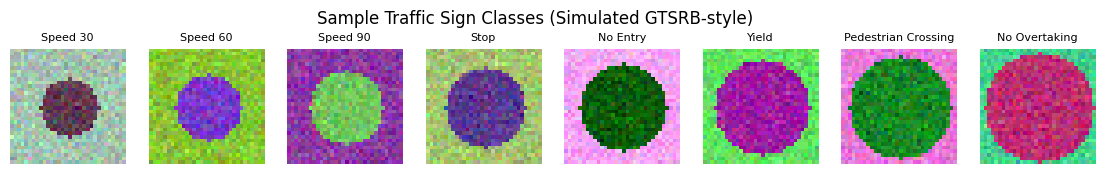

In [4]:
fig, axes = plt.subplots(1, N_CLASSES, figsize=(14, 2))
for c in range(N_CLASSES):
    axes[c].imshow(X[c * N_PER_CLASS])
    axes[c].set_title(CLASS_NAMES[c], fontsize=8)
    axes[c].axis("off")
plt.suptitle("Sample Traffic Sign Classes (Simulated GTSRB-style)")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat = to_categorical(y_test, N_CLASSES)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1600, 32, 32, 3) Test: (400, 32, 32, 3)


In [6]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(N_CLASSES, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,840 (2.08 MB)

 Trainable params: 544,840 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.8176 - loss: 0.6722 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9978 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 4.4564e-04
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 5.6793e-05
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 4.6080e-05
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 1.4054e-05
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 1.7160e-05
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 1.0000 - loss: 8.1923e-04 - val_accuracy: 1.0000 - val_loss: 7.5990e-06
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 1.0000 - loss: 0.001

Test Accuracy: 1.000 | Test Loss: 0.000


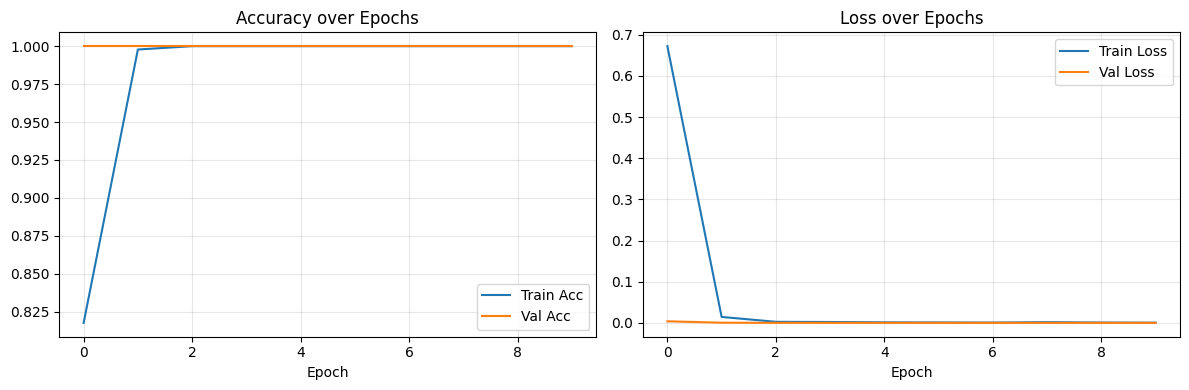

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.3f} | Test Loss: {test_loss:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Train Acc")
axes[0].plot(history.history["val_accuracy"], label="Val Acc")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

                     precision    recall  f1-score   support

           Speed 30       1.00      1.00      1.00        50
           Speed 60       1.00      1.00      1.00        50
           Speed 90       1.00      1.00      1.00        50
               Stop       1.00      1.00      1.00        50
           No Entry       1.00      1.00      1.00        50
              Yield       1.00      1.00      1.00        50
Pedestrian Crossing       1.00      1.00      1.00        50
      No Overtaking       1.00      1.00      1.00        50

           accuracy                           1.00       400
          macro avg       1.00      1.00      1.00       400
       weighted avg       1.00      1.00      1.00       400



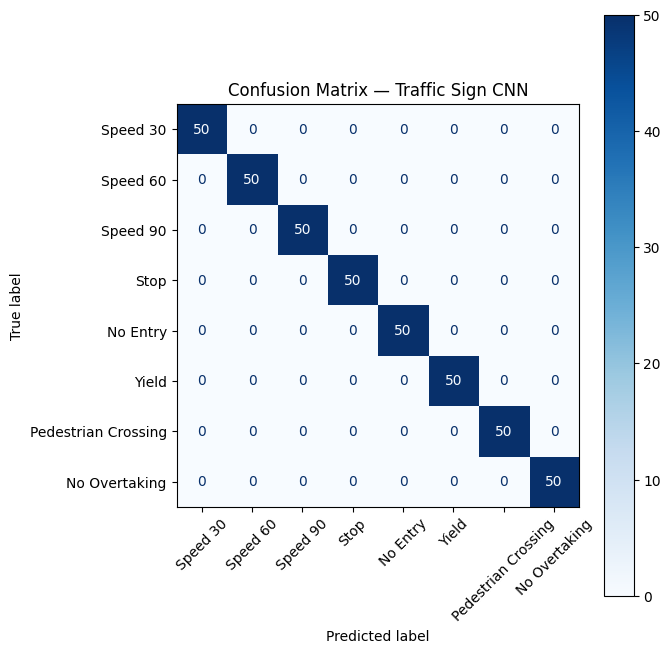

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Traffic Sign CNN")
plt.tight_layout()
plt.show()